In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [11]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current Folder:
c:\Users\Niharika\Hate Speech Detection\notebook

Files:
['training.ipynb']


In [9]:
df = pd.read_csv("labeled_data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'labeled_data.csv'

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df.head()

,count,hate_speech,offensive_language,neither,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
df.shape

(24783, 6)

In [ ]:
df.columns

Index(['count', 'hate_speech', 'offensive_language', 'neither', 'class',
       'tweet'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   count               24783 non-null  int64 
 1   hate_speech         24783 non-null  int64 
 2   offensive_language  24783 non-null  int64 
 3   neither             24783 non-null  int64 
 4   class               24783 non-null  int64 
 5   tweet               24783 non-null  object
dtypes: int64(5), object(1)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

count                 0
hate_speech           0
offensive_language    0
neither               0
class                 0
tweet                 0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['class'].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

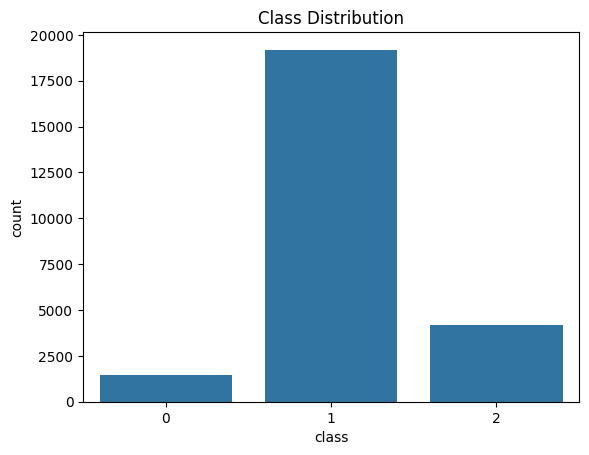

In [ ]:
sns.countplot(x='class', data=df)

plt.title("Class Distribution")
plt.show()

In [ ]:
df[["tweet","class"]].head(10)

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",1
6,"!!!!!!""@__BrighterDays: I can not just sit up ...",1
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,1
8,""" &amp; you might not get ya bitch back &amp; ...",1
9,""" @rhythmixx_ :hobbies include: fighting Maria...",1


In [ ]:
label_map = {
    0:"Hate Speech",
    1:"Offensive Language",
    2:"Neither"
}
df['label_name'] = df['class'].map(label_map)

In [ ]:
df.head()

,count,hate_speech,offensive_language,neither,class,tweet,label_name
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neither
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language


In [ ]:
df['label_name'].value_counts()

label_name
Offensive Language    19190
Neither                4163
Hate Speech            1430
Name: count, dtype: int64

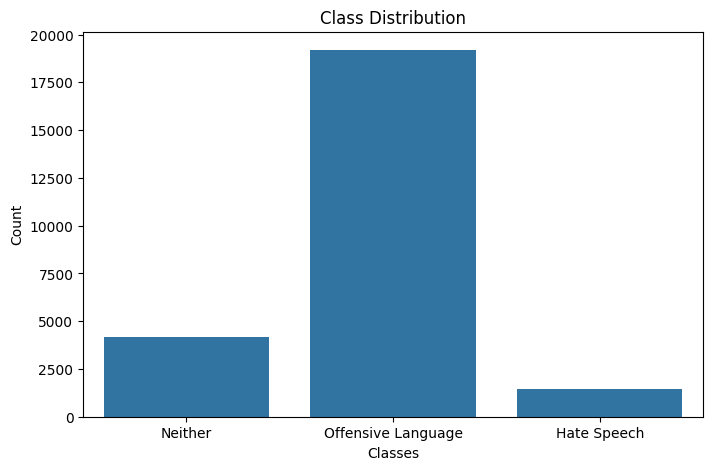

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(x='label_name', data=df)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

In [ ]:
df['text_length'] = df['tweet'].apply(len)

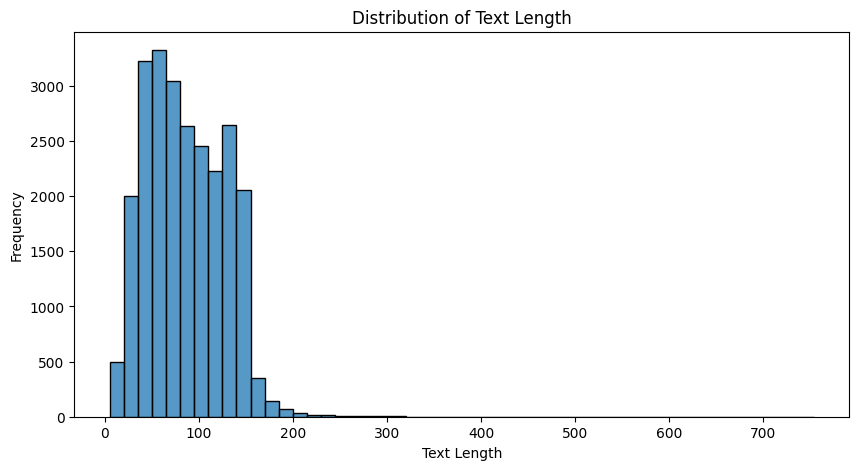

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

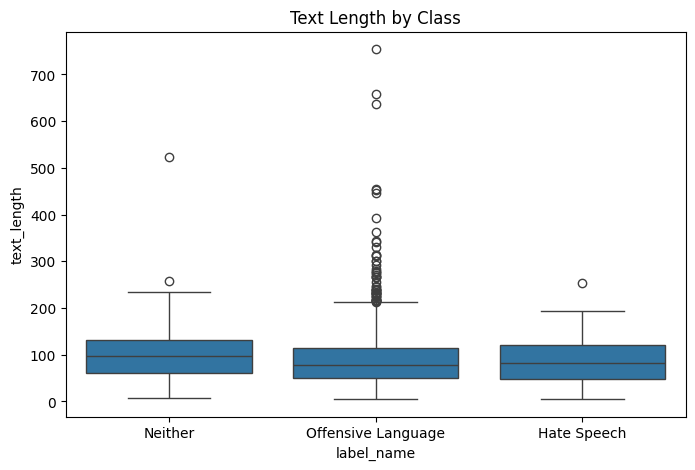

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label_name', y='text_length', data=df)
plt.title("Text Length by Class")
plt.show()

In [ ]:
all_text = " ".join(df['tweet'].astype(str))

In [ ]:
words = all_text.split()

In [ ]:
words

['!!!',
 'RT',
 '@mayasolovely:',
 'As',
 'a',
 'woman',
 'you',
 "shouldn't",
 'complain',
 'about',
 'cleaning',
 'up',
 'your',
 'house.',
 '&amp;',
 'as',
 'a',
 'man',
 'you',
 'should',
 'always',
 'take',
 'the',
 'trash',
 'out...',
 '!!!!!',
 'RT',
 '@mleew17:',
 'boy',
 'dats',
 'cold...tyga',
 'dwn',
 'bad',
 'for',
 'cuffin',
 'dat',
 'hoe',
 'in',
 'the',
 '1st',
 'place!!',
 '!!!!!!!',
 'RT',
 '@UrKindOfBrand',
 'Dawg!!!!',
 'RT',
 '@80sbaby4life:',
 'You',
 'ever',
 'fuck',
 'a',
 'bitch',
 'and',
 'she',
 'start',
 'to',
 'cry?',
 'You',
 'be',
 'confused',
 'as',
 'shit',
 '!!!!!!!!!',
 'RT',
 '@C_G_Anderson:',
 '@viva_based',
 'she',
 'look',
 'like',
 'a',
 'tranny',
 '!!!!!!!!!!!!!',
 'RT',
 '@ShenikaRoberts:',
 'The',
 'shit',
 'you',
 'hear',
 'about',
 'me',
 'might',
 'be',
 'true',
 'or',
 'it',
 'might',
 'be',
 'faker',
 'than',
 'the',
 'bitch',
 'who',
 'told',
 'it',
 'to',
 'ya',
 '&#57361;',
 '!!!!!!!!!!!!!!!!!!"@T_Madison_x:',
 'The',
 'shit',
 'just',


In [ ]:
from collections import Counter
word_freq = Counter(words)
word_freq

Counter({'a': 9099,
         'RT': 7539,
         'bitch': 6638,
         'the': 6590,
         'I': 6472,
         'to': 5240,
         'you': 4881,
         'and': 3670,
         'that': 3111,
         'my': 3072,
         'in': 2902,
         'is': 2759,
         'bitches': 2576,
         'like': 2534,
         'of': 2503,
         'on': 2361,
         'be': 2304,
         'me': 2249,
         'for': 2023,
         'hoes': 1925,
         'with': 1778,
         'pussy': 1711,
         'this': 1575,
         "I'm": 1496,
         'hoe': 1470,
         'ass': 1447,
         'it': 1445,
         'your': 1423,
         'get': 1328,
         'up': 1313,
         'just': 1259,
         "don't": 1243,
         'but': 1242,
         'all': 1206,
         'got': 1198,
         'they': 1175,
         'u': 1128,
         'was': 1117,
         'so': 1112,
         'fuck': 1067,
         'are': 1054,
         'at': 1028,
         'her': 1027,
         'these': 1017,
         'no': 999,
         '

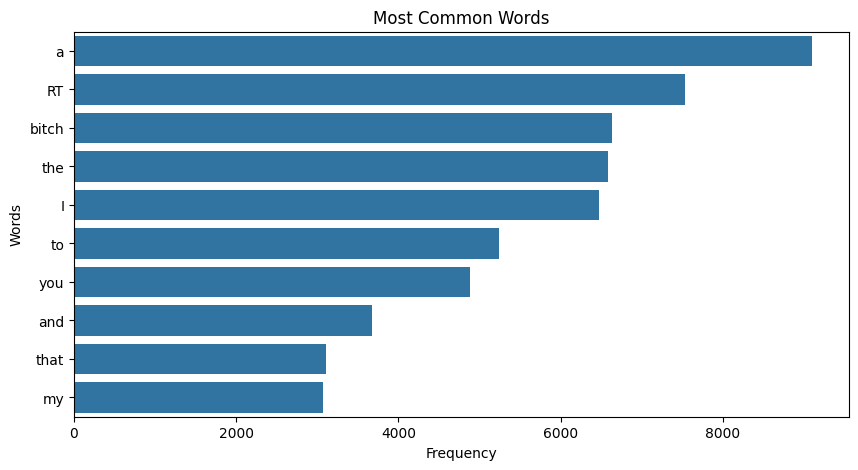

In [ ]:
common_words = word_freq.most_common(10)
words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]
plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [ ]:
hate_text = " ".join(
    df[df['label_name'] == 'Hate Speech']['tweet'].astype(str)
)

In [ ]:
hate_words = hate_text.split()
hate_freq = Counter(hate_words)
hate_freq.most_common(20)

[('a', 530),
 ('the', 349),
 ('you', 348),
 ('to', 320),
 ('RT', 320),
 ('I', 296),
 ('and', 219),
 ('is', 194),
 ('bitch', 164),
 ('that', 161),
 ('like', 157),
 ('in', 154),
 ('of', 148),
 ('faggot', 148),
 ('be', 129),
 ('my', 128),
 ('ass', 127),
 ('your', 117),
 ('white', 116),
 ('are', 112)]

In [ ]:
import re
import nltk

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Niharika\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Niharika\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Niharika\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Niharika\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
stop_words = set(stopwords.words('english'))

In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove html artifacts
    text = re.sub(r'&amp;', '', text)

    # remove RT
    text = re.sub(r'\brt\b', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove html artifacts
    text = re.sub(r'&amp;|&lt;|&gt;', '', text)
    # normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove punctuation/special chars
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # remove tiny leftover tokens
    tokens = [word for word in tokens if len(word) > 2]

    return " ".join(tokens)

In [ ]:
sample_text = df['tweet'][100]
print("Original Text:\n")
print(sample_text)
print("\nCleaned Text:\n")
print(clean_text(sample_text))

Original Text:

"@ClicquotSuave: LMAOOOOOOOOOOO this nigga @Krillz_Nuh_Care http://t.co/AAnpSUjmYI" &lt;bitch want likes for some depressing shit..foh

Cleaned Text:

lmaoo nigga bitch want like depressing shitfoh


In [ ]:
df['clean_text'] = df['tweet'].apply(clean_text)

In [ ]:
df.head()

,count,hate_speech,offensive_language,neither,class,tweet,label_name,text_length,clean_text
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,Neither,140,woman shouldnt complain cleaning house man alw...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,Offensive Language,85,boy dat coldtyga dwn bad cuffin dat hoe place
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,Offensive Language,120,dawg ever fuck bitch start cry confused shit
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,Offensive Language,62,look like tranny
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,Offensive Language,137,shit hear might true might faker bitch told


In [ ]:
df[['tweet', 'clean_text']].head(10)

,tweet,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,woman shouldnt complain cleaning house man alw...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dat coldtyga dwn bad cuffin dat hoe place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg ever fuck bitch start cry confused shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,shit hear might true might faker bitch told
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just...",shit blow meclaim faithful somebody still fuck...
6,"!!!!!!""@__BrighterDays: I can not just sit up ...",sit hate another bitch got much shit going
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of...,cause tired big bitch coming skinny girl
8,""" &amp; you might not get ya bitch back &amp; ...",might get bitch back thats
9,""" @rhythmixx_ :hobbies include: fighting Maria...",hobby include fighting mariam bitch


In [ ]:
stop_words = set(stopwords.words('english'))
negation_words = {'no', 'not', 'nor'}
stop_words = stop_words - negation_words

In [ ]:
(df['clean_text'].str.strip() == '').sum()

np.int64(22)

In [ ]:
df = df[df['clean_text'].str.strip() != '']

In [ ]:
(df['clean_text'].str.strip()=='').sum()

np.int64(0)

In [ ]:
df.shape

(24761, 9)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [ ]:
X = tfidf.fit_transform(df['clean_text'])

In [ ]:
y = df['class']

In [ ]:
X.shape

(24761, 10000)

In [ ]:
tfidf.get_feature_names_out()[:20]

array(['aap', 'aaron', 'ability', 'able', 'abo', 'abortion', 'absolute',
       'absolutely', 'abt', 'abu', 'abuse', 'abused', 'abusive', 'accent',
       'accept', 'accept fact', 'acceptable', 'accident', 'accidentally',
       'according'], dtype=object)

In [ ]:
type(X)

scipy.sparse._csr.csr_matrix

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(19808, 10000)
(4953, 10000)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

In [ ]:
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
accuracy_score(y_test, y_pred_lr)

0.851201292146174

In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.33      0.58      0.42       285
           1       0.96      0.85      0.91      3837
           2       0.74      0.94      0.82       831

    accuracy                           0.85      4953
   macro avg       0.68      0.79      0.72      4953
weighted avg       0.89      0.85      0.86      4953



In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[ 165   91   29]
 [ 315 3274  248]
 [  25   29  777]]


In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
nb_model = MultinomialNB()

In [ ]:
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [ ]:
y_pred_nb = nb_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_nb)

0.8364627498485766

In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       1.00      0.00      0.01       285
           1       0.83      0.99      0.90      3837
           2       0.89      0.41      0.56       831

    accuracy                           0.84      4953
   macro avg       0.91      0.47      0.49      4953
weighted avg       0.85      0.84      0.80      4953



In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

[[   1  278    6]
 [   0 3802   35]
 [   0  491  340]]


In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svm_model = LinearSVC(
    class_weight='balanced',
    max_iter=5000
)

In [ ]:
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,None


In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
accuracy_score(y_test, y_pred_svm)

0.8762366242681203

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.40      0.39      0.39       285
           1       0.93      0.92      0.93      3837
           2       0.78      0.86      0.82       831

    accuracy                           0.88      4953
   macro avg       0.70      0.72      0.71      4953
weighted avg       0.88      0.88      0.88      4953



In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

[[ 111  149   25]
 [ 147 3514  176]
 [  20   96  715]]


In [ ]:
model_results = {
    "Logistic Regression": {
        "Accuracy": 0.8512,
        "Macro F1": 0.72
    },
    "Naive Bayes": {
        "Accuracy": 0.8364,
        "Macro F1": 0.49
    },
    "LinearSVC": {
        "Accuracy": 0.8762,
        "Macro F1": 0.71
    }
}

In [ ]:
results_df = pd.DataFrame(model_results).T
results_df

,Accuracy,Macro F1
Logistic Regression,0.8512,0.72
Naive Bayes,0.8364,0.49
LinearSVC,0.8762,0.71


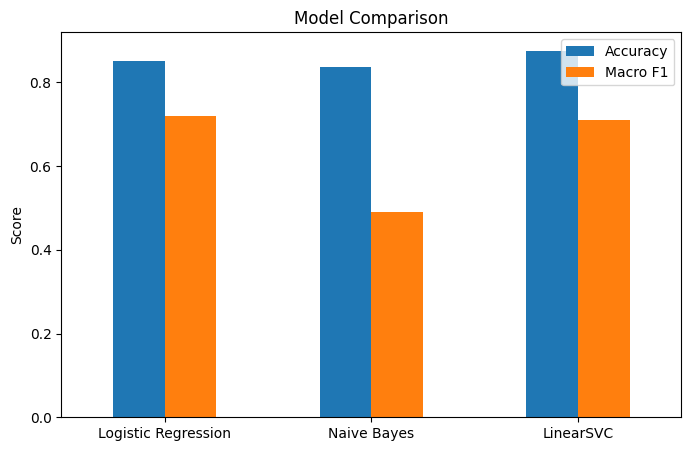

In [ ]:
results_df.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [ ]:
loaded_model = joblib.load("final_model.pkl")
loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

NameError: name 'joblib' is not defined

In [ ]:
def predict_hate_speech(text):
    cleaned = clean_text(text)
    vectorized = loaded_vectorizer.transform([cleaned])
    prediction = loaded_model.predict(vectorized)[0]
    label_map = {
        0: "Hate Speech",
        1: "Offensive Language",
        2: "Neither"
    }
    return label_map[prediction]

In [ ]:
predict_hate_speech("I hate you")

'Hate Speech'

In [ ]:
predict_hate_speech("Good morning Everyone")

'Offensive Language'

In [ ]:
predict_hate_speech("You are stupid idiot")

'Hate Speech'